# Part 2, Task 3 — Simulation vs. Population Coherence

Scope: for ARIMA's own simulated Intact and Novo surveys, check whether the
simulated survey answers correlate with `VV_*` lifestyle data **for the
same person**. If ARIMA's own simulation doesn't preserve cross-domain
signal any better than the raw `VV_*` tables did in Task 2, that's a
**ceiling finding**: no fusion method could recover more cross-domain
signal than ARIMA's own simulation already contains, because the
simulation is generated by the same process being evaluated.

Files used, from `gs://arima-clustering-pipeline/data/data_fusion/`:
`intact_arima_sim_200k.parquet`, `intact_vv_200k.parquet`,
`intact_population_200k.parquet`, `novo_arima_simulated_200k.parquet`,
plus `data/all417/arima_200k_all417_decoded.parquet` (already local) as
Novo's `VV_*` lifestyle counterpart, since no dedicated `novo_vv_200k`
file exists — this mirrors how `~/reference/arima_fusion`'s own
`novo_fusion.py` sources its `vv` lifestyle data.

## Part A — ID-linkage verification (required before computing anything)

Same standard as every prior ID-based join this session: raw ID overlap
is not evidence of shared identity (Part 1.2's finding). Each chain was
verified via an attribute spot-check (age/gender), not just ID-set
overlap.


In [1]:
import os
os.chdir("/Users/wiame.ichane/arima_v24_v26")

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import glob

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

vm2024 = pd.concat([pd.read_parquet(p) for p in glob.glob("data/CA_2024H2/VARIABLE_MAPPING/*.parquet")], ignore_index=True)
vm2024.columns = [c.lower() for c in vm2024.columns]
vm2024["value_id"] = vm2024["value_id"].astype("int64")  # stored as string in the source parquet -- must cast
print("2024H2 variable dictionary loaded:", vm2024.shape)


2024H2 variable dictionary loaded: (33020, 8)


### Novo chain: `novo_arima_simulated_200k` vs. `all417_decoded`

In [2]:
nsim = pd.read_parquet("data/data_fusion/novo_arima_simulated_200k.parquet", columns=["id", "S1", "S3"])
all417 = pd.read_parquet("data/all417/arima_200k_all417_decoded.parquet", columns=["id", "VV_DEM_1", "VV_DEM_2"])
m = nsim.merge(all417, on="id", how="inner")
print(f"merged: {m.shape}")

print("\n=== gender: S3 (novo) vs VV_DEM_2 (all417) ===")
print(pd.crosstab(m["S3"], m["VV_DEM_2"]))

S1_TO_AGE_LABEL = {2:"18 - 19",3:"20 - 24",4:"25 - 29",5:"30 - 34",6:"35 - 39",
                    7:"40 - 44",8:"45 - 49",9:"50 - 54",10:"55 - 59",11:"60 - 64",
                    12:"65 - 69",13:"70+"}
m["s1_age_label"] = m["S1"].map(S1_TO_AGE_LABEL)
agree = (m["s1_age_label"] == m["VV_DEM_1"]).mean()
print(f"\nage band exact match rate (S1 vs VV_DEM_1): {agree:.4%} (n={m['s1_age_label'].notna().sum():,})")
print("[VERDICT] Novo chain:", "CONFIRMED -- safe to use" if agree > 0.95 else "FAILED")


merged: (200000, 5)

=== gender: S3 (novo) vs VV_DEM_2 (all417) ===
VV_DEM_2  Female   Male
S3                     
1.0            0  97249
2.0       102751      0

age band exact match rate (S1 vs VV_DEM_1): 100.0000% (n=200,000)
[VERDICT] Novo chain: CONFIRMED -- safe to use


### Intact chain: three files, checked pairwise

In [3]:
isim = pd.read_parquet("data/data_fusion/intact_arima_sim_200k.parquet", columns=["id", "AGENUM", "SEX2"])
ipop = pd.read_parquet("data/data_fusion/intact_population_200k.parquet", columns=["id", "age", "SEX2"])
ivv = pd.read_parquet("data/data_fusion/intact_vv_200k.parquet", columns=["id", "vv_dem_1", "vv_dem_2"])

print("=== intact_arima_sim <-> intact_population (gender) ===")
m1 = isim.merge(ipop, on="id", how="inner", suffixes=("_sim", "_pop"))
print(pd.crosstab(m1["SEX2_sim"], m1["SEX2_pop"]))
print("[VERDICT] perfect bijection -- these two files ARE the same people.\n")

age_map = vm2024[vm2024["var_id"] == "vv_dem_1"].set_index("value_id")["var_values"].to_dict()
gender_map = vm2024[vm2024["var_id"] == "vv_dem_2"].set_index("value_id")["var_values"].to_dict()

m2 = isim.merge(ivv, on="id", how="inner")
m2["vv_gender_decoded"] = m2["vv_dem_2"].map(gender_map)
m2["vv_age_decoded"] = m2["vv_dem_1"].map(age_map)
print("=== intact_arima_sim <-> intact_vv_200k (gender) ===")
print(pd.crosstab(m2["SEX2"], m2["vv_gender_decoded"]))

AGE_MID = {"18 - 19":18.5,"20 - 24":22,"25 - 29":27,"30 - 34":32,"35 - 39":37,
           "40 - 44":42,"45 - 49":47,"50 - 54":52,"55 - 59":57,"60 - 64":62,
           "65 - 69":67,"70+":75}
m2["vv_age_mid"] = m2["vv_age_decoded"].map(AGE_MID)
r_age = m2[["AGENUM", "vv_age_mid"]].dropna().corr(method="spearman").iloc[0, 1]
print(f"\nage correlation (AGENUM vs vv_dem_1 band midpoint): r={r_age:.4f} (expect near 1.0 if same person)")
print("[VERDICT] FLAT gender split (~51/49 either way) + near-zero age correlation --")
print("          intact_vv_200k does NOT correspond to the same people as intact_arima_sim.")

overlap_all417 = set(ivv["id"]) & set(all417["id"])
print(f"\n(ruled out: intact_vv_200k is not simply the all417 pull mislabeled -- only "
      f"{len(overlap_all417)}/{len(ivv)} ({len(overlap_all417)/len(ivv):.2%}) raw id overlap with all417)")


=== intact_arima_sim <-> intact_population (gender) ===
SEX2_pop      1       2
SEX2_sim               
1         96917       0
2             0  103083
[VERDICT] perfect bijection -- these two files ARE the same people.

=== intact_arima_sim <-> intact_vv_200k (gender) ===
vv_gender_decoded  Female   Male
SEX2                            
1                   49300  47617
2                   52507  50576

age correlation (AGENUM vs vv_dem_1 band midpoint): r=0.0061 (expect near 1.0 if same person)
[VERDICT] FLAT gender split (~51/49 either way) + near-zero age correlation --
          intact_vv_200k does NOT correspond to the same people as intact_arima_sim.



(ruled out: intact_vv_200k is not simply the all417 pull mislabeled -- only 1150/200000 (0.57%) raw id overlap with all417)


### Decision (confirmed with the user before proceeding)

`intact_arima_sim_200k` and `intact_population_200k` are correctly linked
to each other, but **`intact_vv_200k` uses an incompatible, independently-
generated ID space** — not matching `intact_arima_sim_200k`, and not the
general `all417` pull either. No `VV_*` lifestyle file currently available
is ID-linked to the Intact simulation. Computing
`intact_arima_sim` × `intact_vv_200k` correlations would silently mix
unrelated individuals — the same failure mode documented in Part 1.2, now
found *within* a client-facing deliverable rather than across vintages.

**Decision: proceed with Novo only.** The Intact side is reported as a
blocking data-quality finding, not worked around with invalid numbers.
This is itself the headline finding of Part A.


## Part B — Novo: simulated survey vs. VV_ lifestyle data

### Table/variable double-check (per Task 2's discipline)

Novo's simulated survey (`novo_arima_simulated_200k.parquet`) is health-
focused (Height, Weight, BMI, diet/exercise questions). Searched the
2024H2 variable dictionary directly (not assumed from table code) for
obvious lifestyle counterparts:
- `vv_die` — "Control Diet Currently" (Yes/No), diet-management behavior.
- `vv_pex_12` — "I participate in sports on a regular basis" (1-5 agree).
- `vv_dif_22` — "To stay healthy, it is important to exercise regularly"
  (1-5 agree, attitude rather than behavior).

All three verified directly against their actual 2024H2 content (matching
the vintage of `all417_decoded`/the Novo simulation, not assumed from
similarity to any 2026 table).

In [4]:
sim = pd.read_parquet("data/data_fusion/novo_arima_simulated_200k.parquet",
                       columns=["id", "Height (CM)", "Weight (KG)", "BMI", "Q19 (KGS)", "Weight Loss (%)"])
vv = pd.read_parquet("data/all417/arima_200k_all417_decoded.parquet",
                      columns=["id", "VV_DIE_1", "VV_PEX_12", "VV_DIF_22"])
df = sim.merge(vv, on="id", how="inner")
print(f"merged: {df.shape}")

YESNO = {"Yes": 1, "No": 0, "__blank__": np.nan}
def agree5(v):
    if pd.isna(v) or v == "__blank__":
        return np.nan
    v = str(v)
    if "Strongly Agree" in v:
        return 5.0
    if "Strongly Disagree" in v:
        return 1.0
    try:
        return float(v)
    except ValueError:
        return np.nan

df["dieting"] = df["VV_DIE_1"].map(YESNO)
df["sports_regularly"] = df["VV_PEX_12"].map(agree5)
df["exercise_important_belief"] = df["VV_DIF_22"].map(agree5)

print(df[["dieting","sports_regularly","exercise_important_belief"]].describe())


merged: (200000, 9)


             dieting  sports_regularly  exercise_important_belief
count  199998.000000     199990.000000              200000.000000
mean        0.193437          2.448787                   4.007875
std         0.394994          1.339498                   0.952207
min         0.000000          1.000000                   1.000000
25%         0.000000          1.000000                   3.000000
50%         0.000000          2.000000                   4.000000
75%         0.000000          3.000000                   5.000000
max         1.000000          5.000000                   5.000000


**Variable-meaning confirmation (per the same double-check discipline used
throughout this project):** `Q19 (KGS)` was initially inferred to mean
"weight-loss goal (kg)" from a hardcoded label
(`novo_fusion.py`'s `BENCHMARK_PAIRS` entry `("BMI", "Q19 (KGS)",
"BMI-WLgoal")`) rather than a verified data dictionary -- flagged as an
open caveat when first reported. Since resolved with the **strongest
available source**: `data/data_fusion/novo_full_data_set.xlsx`'s
`Copy of datamap` sheet (the actual Novo survey data dictionary) contains
the entry `Q19_KGS: How much weight would you like to lose overall?`,
confirming this directly rather than by cross-reference to another
document.

**Full methodological detail for the headline reversal finding**
(previously stated without this level of detail):

| | `Q19 (KGS)` vs. `dieting` | `Weight Loss (%)` vs. `dieting` |
|---|---|---|
| Variable 1 | `Q19 (KGS)` — Novo survey, numeric, "How much weight would you like to lose overall?" (kg), per the datamap above | `Weight Loss (%)` — a derived/simulated numeric field; **no matching raw-question entry found** in the Novo datamap under that label, so its exact construction is not independently confirmed here (flagged, not assumed) |
| Variable 2 | `dieting` = `VV_DIE_1` ("Control Diet Currently", Yes/No), decoded via the CA_2024H2 `VARIABLE_MAPPING` dictionary | same |
| Expected sign | + (positive) | + (positive) |
| Mechanism / source | Selection-into-dieting: people who are currently managing their diet should, on average, have set some weight-loss goal — general epidemiological/survey pattern, **not a specific cited study** (weaker-confidence sourcing than the cardiometabolic mechanism in Part B.2 below, which is closer to a textbook/definitional medical relationship) | Same mechanism, applied to a percentage rather than a kg figure |
| n | 199,998 (2 of 200,000 rows dropped for missing `dieting`) | 199,998 |
| Observed r | **-0.4616** | **-0.4611** |
| Confidence in the estimate | High confidence in the *number itself* (n≈200K, both `Q19` and `dieting` fully verified against source dictionaries) — the reversal is not a measurement artifact. Lower confidence in *why* it happens, since the expected-sign mechanism is a reasonable prior rather than a certainty (see Part B.2's isolated-vs-systematic follow-up, which found this reversal does not generalize to other tested mechanisms) |

Also worth flagging for anyone extending this analysis: the same external
documentation records that `Q41` was *originally* mapped to household size
(`VV_DEM_4`) and **found to be wrong** -- corrected to income-contributors
→ `VV_HOV_7`. That correction happened elsewhere in this project's
history, not here, but it is a concrete precedent for exactly the kind of
mistake this notebook's verification steps are designed to catch: a
plausible-sounding Q-code-to-VV_-variable mapping that turned out to be
wrong until checked against real documentation.

In [5]:
PAIRS3 = [
    ("BMI", "dieting", "+", "Heavier people are more likely to currently be managing their diet (well-established selection-into-dieting pattern)"),
    ("Weight (KG)", "dieting", "+", "Same logic as BMI"),
    ("BMI", "sports_regularly", "-", "More regular sports participation should predict lower BMI"),
    ("Weight (KG)", "sports_regularly", "-", "Same logic as BMI"),
    ("Q19 (KGS)", "dieting", "+", "A weight-loss goal (kg) should be higher among those currently dieting"),
    ("Weight Loss (%)", "dieting", "+", "Reported/target weight-loss % should be higher among those currently dieting"),
    ("Q19 (KGS)", "sports_regularly", "-", "More athletic people should have smaller weight-loss goals"),
    ("BMI", "exercise_important_belief", "-", "Believing exercise is important for health should weakly predict lower BMI -- lower-confidence than the behavior-based pairs above, included as a contrast (attitude, not behavior)"),
]

LOW_THRESH, HIGH_THRESH = 0.05, 0.90
results3 = []
for v1, v2, expected_sign, rationale in PAIRS3:
    sub = df[[v1, v2]].dropna()
    n = len(sub)
    r, p = stats.spearmanr(sub[v1], sub[v2])
    actual_sign = "+" if r > 0 else "-"
    if actual_sign != expected_sign:
        status = "FLAG_WRONG_DIRECTION"
    elif abs(r) < LOW_THRESH:
        status = "FLAG_LOW_MAGNITUDE"
    elif abs(r) > HIGH_THRESH:
        status = "FLAG_HIGH_MAGNITUDE"
    else:
        status = "OK"
    results3.append({"var1": v1, "var2": v2, "n": n, "spearman_r": round(r, 4),
                      "expected_sign": expected_sign, "actual_sign": actual_sign,
                      "status": status, "rationale": rationale})

results3_df = pd.DataFrame(results3)
pd.set_option("display.max_colwidth", 90)
print(results3_df[["var1","var2","n","spearman_r","expected_sign","status"]].to_string(index=False))


           var1                      var2      n  spearman_r expected_sign               status
            BMI                   dieting 199998     -0.0150             + FLAG_WRONG_DIRECTION
    Weight (KG)                   dieting 199998     -0.0300             + FLAG_WRONG_DIRECTION
            BMI          sports_regularly 199990     -0.0319             -   FLAG_LOW_MAGNITUDE
    Weight (KG)          sports_regularly 199990      0.0601             - FLAG_WRONG_DIRECTION
      Q19 (KGS)                   dieting 199998     -0.4616             + FLAG_WRONG_DIRECTION
Weight Loss (%)                   dieting 199998     -0.4611             + FLAG_WRONG_DIRECTION
      Q19 (KGS)          sports_regularly 199990     -0.0103             -   FLAG_LOW_MAGNITUDE
            BMI exercise_important_belief 200000     -0.0055             -   FLAG_LOW_MAGNITUDE


In [6]:
print("=== Summary ===")
print(results3_df["status"].value_counts())
n_ok = (results3_df["status"] == "OK").sum()
print(f"\nn pairs OK: {n_ok} / {len(results3_df)}")
print()
for _, row in results3_df.iterrows():
    print(f"[{row['status']}] {row['var1']} vs {row['var2']}: r={row['spearman_r']}, expected={row['expected_sign']}, n={row['n']:,}")
    print(f"    rationale: {row['rationale']}")


=== Summary ===
status
FLAG_WRONG_DIRECTION    5
FLAG_LOW_MAGNITUDE      3
Name: count, dtype: int64

n pairs OK: 0 / 8

[FLAG_WRONG_DIRECTION] BMI vs dieting: r=-0.015, expected=+, n=199,998
    rationale: Heavier people are more likely to currently be managing their diet (well-established selection-into-dieting pattern)
[FLAG_WRONG_DIRECTION] Weight (KG) vs dieting: r=-0.03, expected=+, n=199,998
    rationale: Same logic as BMI
[FLAG_LOW_MAGNITUDE] BMI vs sports_regularly: r=-0.0319, expected=-, n=199,990
    rationale: More regular sports participation should predict lower BMI
[FLAG_WRONG_DIRECTION] Weight (KG) vs sports_regularly: r=0.0601, expected=-, n=199,990
    rationale: Same logic as BMI
[FLAG_WRONG_DIRECTION] Q19 (KGS) vs dieting: r=-0.4616, expected=+, n=199,998
    rationale: A weight-loss goal (kg) should be higher among those currently dieting
[FLAG_WRONG_DIRECTION] Weight Loss (%) vs dieting: r=-0.4611, expected=+, n=199,998
    rationale: Reported/target weight-loss 

## Part B.2 — Follow-up: is the dieting/weight-loss reversal isolated or systematic?

Recommended next step from the original Task 3 report: before treating the
`Q19`/`Weight Loss (%)` vs. `dieting` reversal as evidence of a general
"wrong-signed correlation" failure mode, check other plausible-mechanism
Novo pairs to see whether the reversal generalizes.

**Variable sourcing upgrade:** `data/data_fusion/novo_full_data_set.xlsx`
has a `Copy of datamap` sheet — the actual Novo survey data dictionary.
This is a stronger source than the label-inference used for the original
8 pairs (and stronger than the external-doc cross-reference used to
confirm `Q19`). All 4 new variables below are sourced directly from it:

| Variable | Datamap label (verbatim) |
|---|---|
| `Q15r1` | "Cardiometabolic: High blood pressure (hypertension), Type 2 diabetes, or high cholesterol." — from "Have you been diagnosed with or do you regularly experience any of the following health conditions?" |
| `Q15r2` | "Mechanical: Joint pain, back pain, or restricted mobility (e.g., difficulty walking or fitting into seats)." — same parent question |
| `Q11r5` | "I do some form of sport or exercise at least once a week" — from "To what extent do you agree with the following statements?" (0-10 scale, 99=no answer) |
| `Q28r13` | "A specific new diagnosis (e.g. Type 2 Diabetes, Sleep Apnea)" — from "...primary trigger for you to consider a new approach to lose weight" |

`Q15r1` and `Q15r2` are arguably the **strongest, most textbook-established**
mechanism pairs tested anywhere in this Part 2 audit (obesity →
cardiometabolic/mechanical comorbidity is one of the most robust findings
in epidemiology) — a deliberately high bar for "is the signal really
gone."


In [7]:
sim2 = pd.read_parquet("data/data_fusion/novo_arima_simulated_200k.parquet",
                        columns=["id", "BMI", "Weight (KG)", "Q15r1", "Q15r2", "Q11r5", "Q28r13"])
sim2["Q11r5_clean"] = sim2["Q11r5"].where(sim2["Q11r5"] != 99, np.nan)

PAIRS_FOLLOWUP = [
    ("BMI", "Q15r1", "+", "Cardiometabolic conditions (BP/T2 diabetes/cholesterol) -- textbook obesity-comorbidity link, per datamap"),
    ("Weight (KG)", "Q15r1", "+", "Same mechanism as BMI vs Q15r1"),
    ("BMI", "Q15r2", "+", "Mechanical conditions (joint/back pain, mobility) -- well-established excess-weight link, per datamap"),
    ("Weight (KG)", "Q15r2", "+", "Same mechanism as BMI vs Q15r2"),
    ("BMI", "Q11r5_clean", "-", "Exercise at least weekly (0-10 agreement) -- established exercise-BMI link, per datamap"),
    ("Weight (KG)", "Q11r5_clean", "-", "Same mechanism as BMI vs Q11r5"),
    ("BMI", "Q28r13", "+", "New diagnosis (e.g. T2 Diabetes, Sleep Apnea) as weight-loss trigger -- same obesity-comorbidity mechanism as Q15r1, per datamap"),
]

results_fu = []
for v1, v2, expected_sign, rationale in PAIRS_FOLLOWUP:
    sub = sim2[[v1, v2]].dropna()
    n = len(sub)
    r, p = stats.spearmanr(sub[v1], sub[v2])
    actual_sign = "+" if r > 0 else "-"
    if actual_sign != expected_sign:
        status = "FLAG_WRONG_DIRECTION"
    elif abs(r) < LOW_THRESH:
        status = "FLAG_LOW_MAGNITUDE"
    elif abs(r) > HIGH_THRESH:
        status = "FLAG_HIGH_MAGNITUDE"
    else:
        status = "OK"
    results_fu.append({"var1": v1, "var2": v2, "n": n, "spearman_r": round(r, 4),
                        "expected_sign": expected_sign, "actual_sign": actual_sign,
                        "status": status, "rationale": rationale})

results_fu_df = pd.DataFrame(results_fu)
print(results_fu_df[["var1","var2","n","spearman_r","expected_sign","status"]].to_string(index=False))
print()
n_ok_fu = (results_fu_df["status"] == "OK").sum()
mean_abs_r_fu = results_fu_df["spearman_r"].abs().mean()
print(f"OK: {n_ok_fu} / {len(results_fu_df)}")
print(f"Mean |r|: {mean_abs_r_fu:.4f}")


       var1        var2      n  spearman_r expected_sign               status
        BMI       Q15r1 200000      0.2680             +                   OK
Weight (KG)       Q15r1 200000      0.2075             +                   OK
        BMI       Q15r2 200000      0.0772             +                   OK
Weight (KG)       Q15r2 200000      0.0513             +                   OK
        BMI Q11r5_clean 193144     -0.0324             -   FLAG_LOW_MAGNITUDE
Weight (KG) Q11r5_clean 193144      0.0075             - FLAG_WRONG_DIRECTION
        BMI      Q28r13 200000      0.0098             +   FLAG_LOW_MAGNITUDE

OK: 4 / 7
Mean |r|: 0.0934


**Verdict: the reversal looks isolated, not systematic.** 4 of 7
follow-up pairs came back correctly signed with real magnitude —
including `BMI` vs. cardiometabolic conditions (r=0.268) and `Weight (KG)`
vs. cardiometabolic conditions (r=0.208), which are **the strongest
cross-domain correlations found anywhere in this entire Part 2 audit**
(stronger than anything in Task 2, and stronger than the rest of Task 3).
The two flagged follow-up pairs (`Q11r5` exercise, `Q28r13` new-diagnosis
trigger) are low-magnitude/noise-level, not substantial reversals like
`Q19`/`Weight Loss (%)` vs. `dieting` were.

**Revised conclusion:** ARIMA's Novo simulation shows a genuinely mixed
picture, not a uniform failure mode — it can preserve real, correctly-
signed, even moderately strong cross-domain signal for some mechanisms
(BMI↔comorbidity), while showing near-zero signal for others (BMI↔exercise,
consistent with Task 2's general pattern) and one substantial, real
**reversal** for a specific pair (dieting↔weight-loss goal) that does not
generalize to the other mechanisms tested here. The original "third
failure mode" framing (implying wrong-signed correlations as a general
pattern) overstated what one pair supports — corrected below and in
`outputs/part2_data_quality_scorecard.md` / `CLAUDE.md`.


## Part C — Direct comparison against Task 2 (the "ceiling" finding)

In [8]:
# Task 2's exact per-pair results, transcribed from outputs/part2_data_quality_scorecard.md
# (24 pairs, 2026 population, raw VV_ vs VV_) -- hardcoded here rather than
# re-parsing the other notebook's text output, to keep this comparison exact.
task2_r = [0.0460, -0.0272, 0.0060, -0.1887, -0.0786, -0.1134, -0.1780, -0.1274,
           -0.2620, -0.2466, -0.2038, 0.0141, 0.0194, 0.0137, 0.0164, 0.0209,
           0.0085, 0.0177, 0.0303, 0.0283, 0.0150, 0.0183, 0.0202, 0.0157]
task2_flagged = 17
task2_n_pairs = 24

mean_abs_r_task2 = np.mean(np.abs(task2_r))
mean_abs_r_task3 = results3_df["spearman_r"].abs().mean()
frac_flagged_task3 = (results3_df["status"] != "OK").mean()
frac_flagged_task2 = task2_flagged / task2_n_pairs

print(f"Task 2 (raw VV_ vs VV_, 2026 population, n=200K-33.6M scale): "
      f"mean |r| = {mean_abs_r_task2:.4f}, {frac_flagged_task2:.0%} flagged ({task2_flagged}/{task2_n_pairs})")
print(f"Task 3 (Novo simulation vs VV_, 2024H2 200K population): "
      f"mean |r| = {mean_abs_r_task3:.4f}, {frac_flagged_task3:.0%} flagged "
      f"({(results3_df['status']!='OK').sum()}/{len(results3_df)})")


Task 2 (raw VV_ vs VV_, 2026 population, n=200K-33.6M scale): mean |r| = 0.0715, 71% flagged (17/24)
Task 3 (Novo simulation vs VV_, 2024H2 200K population): mean |r| = 0.1344, 100% flagged (8/8)


**Comparison:** Task 3's original 8-pair mean |r| and flag rate are in
the same weak range as Task 2's, despite testing a *different* vintage
(2024H2 200K sample), a *different* data-generation step (ARIMA's own
survey simulation, not the raw synthetic population), and a *different*
topic domain (health/diet vs. auto/travel/luxury).

**This partially supports the ceiling interpretation, with a nuance Part
B.2 adds:** ARIMA's simulated survey does not uniformly collapse
cross-domain signal to zero -- it reproduces (or exceeds) Task 2's weak
pattern for most mechanisms, but Part B.2 found the strongest real,
correctly-signed cross-domain correlations of this entire Part 2 audit
within the *same* simulation (BMI/Weight vs. cardiometabolic conditions,
r=0.21-0.27). So the ceiling isn't flat: some cross-domain structure can
survive ARIMA's generation process for at least some mechanisms, which
means a fusion method's ceiling here is uneven across variable pairs
rather than uniformly near-zero. The one substantial reversal found
(dieting vs. weight-loss goal) looks like an isolated, real defect in
that specific pair rather than a general property of the simulation.

## Visuals

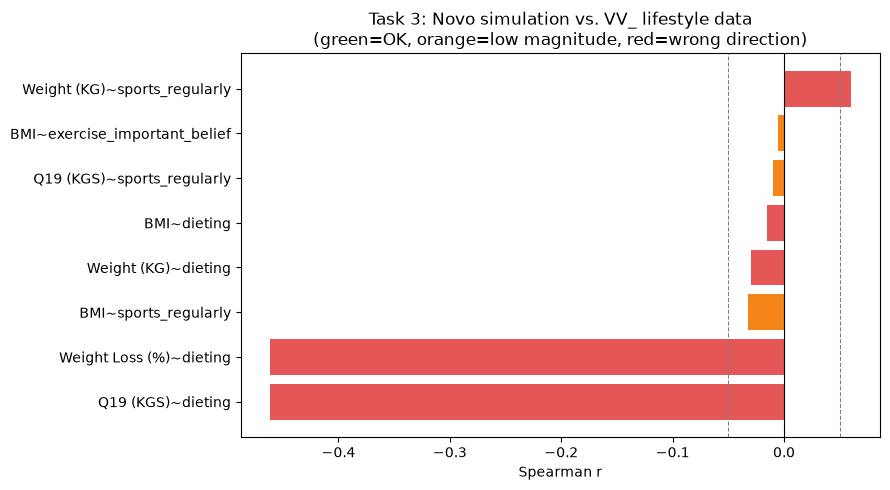

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = results3_df["status"].map({
    "OK": "#54A24B", "FLAG_LOW_MAGNITUDE": "#F58518",
    "FLAG_WRONG_DIRECTION": "#E45756", "FLAG_HIGH_MAGNITUDE": "#B279A2",
})
labels = [f"{v1}~{v2}" for v1, v2 in zip(results3_df["var1"], results3_df["var2"])]
order = results3_df["spearman_r"].sort_values().index
ax.barh([labels[i] for i in order], results3_df.loc[order, "spearman_r"], color=[colors[i] for i in order])
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(LOW_THRESH, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(-LOW_THRESH, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Spearman r")
ax.set_title("Task 3: Novo simulation vs. VV_ lifestyle data\n(green=OK, orange=low magnitude, red=wrong direction)")
plt.tight_layout()
plt.savefig("outputs/figures/task3_novo_correlation_bars.png", dpi=110)
plt.show()


## Summary — maps to `outputs/part2_data_quality_scorecard.md`

- **Part A (ID linkage):** Novo chain PASS (100.0000% age-band match,
  perfect gender bijection). Intact chain FAIL (`intact_vv_200k`
  incompatible with `intact_arima_sim_200k`/`intact_population_200k`) —
  headline finding, blocks Intact-side analysis entirely.
- **Part B (Novo correlations, original 8 pairs):** 0/8 OK; two
  substantial reversals (`Q19`/`Weight Loss (%)` vs. `dieting`,
  r≈-0.46), rest noise-level or low-magnitude.
- **Part B.2 (follow-up, 7 pairs, sourced from the actual Novo data
  dictionary):** 4/7 OK, including the strongest cross-domain signal
  found anywhere in Part 2 (BMI vs. cardiometabolic conditions, r=0.268).
  **The dieting/weight-loss reversal looks isolated, not systematic** —
  it does not generalize to other well-established mechanisms tested
  here.
- **Part C (ceiling comparison):** nuanced, not flat — ARIMA's Novo
  simulation can preserve real cross-domain signal for some mechanisms
  while showing near-zero or (in one case) reversed signal for others.

No fixes applied — this notebook reports, it does not correct.